## Notebook to plot models ran with python files from json results

In [21]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [22]:
sns.set_style("darkgrid")

### Plotting RNN

In [ ]:
base_path = Path('rnn')

# test GRU and LSTM

file_paths = {
    'Count Vectorizer': base_path / 'res_json/results_rnn_count_vectorizer_2_corr.json',
    'POS Tagging': base_path / 'res_json/results_rnn_pos.json',
    'TF-IDF Vectorizer': base_path / 'res_json/results_rnn_tfidf_vectorizer_2_corr.json',
    'Transformer Encoded': base_path / 'res_json/results_rnn_transformer_encoded.json'
}

In [30]:
results = {}
for model_name, file_path in file_paths.items():
    with open(file_path, 'r') as f:
        results[model_name] = json.load(f)

In [31]:
training_history = {}
validation_history = {}
test_metrics = {}

for model_name, data in results.items():
    train_list = []
    val_list = []
    
    for epoch_data in data['history']:
        epoch = epoch_data['epoch']
        
        train_entry = {'epoch': epoch, 'model': model_name}
        train_entry.update(epoch_data['train'])
        train_list.append(train_entry)
        
        val_entry = {'epoch': epoch, 'model': model_name}
        val_entry.update(epoch_data['val'])
        val_list.append(val_entry)
    
    training_history[model_name] = pd.DataFrame(train_list)
    validation_history[model_name] = pd.DataFrame(val_list)
    
    test_entry = {'model': model_name}
    test_entry.update(data['test'])
    test_metrics[model_name] = test_entry

train_combined = pd.concat(training_history.values(), ignore_index=True)
val_combined = pd.concat(validation_history.values(), ignore_index=True)
test_combined = pd.DataFrame(test_metrics).T

In [32]:
test_combined

,model,f1,precision,recall,roc_auc,avg_precision,loss
Count Vectorizer,Count Vectorizer,0.391081,0.404255,0.378738,0.767638,0.406662,0.715495
POS Tagging,POS Tagging,0.385389,0.305361,0.522259,0.741414,0.369692,0.600438
TF-IDF Vectorizer,TF-IDF Vectorizer,0.38716,0.381783,0.392691,0.748722,0.388564,0.669938
Transformer Encoded,Transformer Encoded,0.529024,0.525213,0.53289,0.845363,0.544023,0.566041


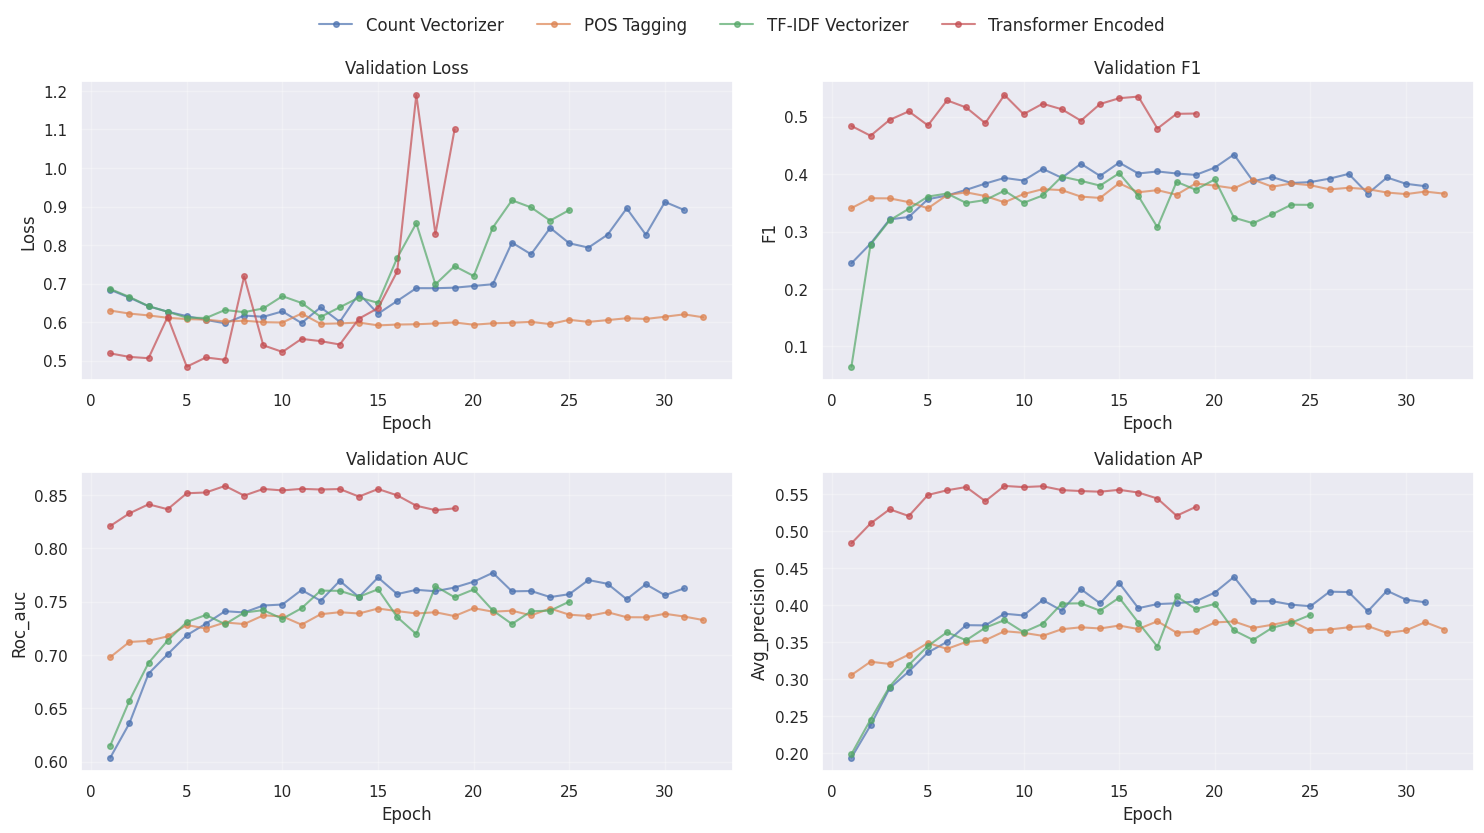

In [39]:
# Plot validation metrics comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 8))

# metrics_val = ['loss', 'f1', 'precision', 'recall', 'roc_auc', 'avg_precision']
# titles_val = ['Validation Loss', 'Validation F1', 'Validation Precision', 'Validation Recall', 'Validation AUC', 'Validation AP']
metrics_val = ['loss', 'f1', 'roc_auc', 'avg_precision']
titles_val = ['Validation Loss', 'Validation F1', 'Validation AUC', 'Validation AP']

for idx, (ax, metric, title) in enumerate(zip(axes.flat, metrics_val, titles_val)):
    for model_name in validation_history.keys():
        df = validation_history[model_name]
        ax.plot(df['epoch'], df[metric], marker='o', label=model_name, alpha=0.7, markersize=4)
    
    ax.set_xlabel('Epoch')
    ax.set_ylabel(metric.capitalize())
    ax.set_title(title, fontsize=12)
    # ax.legend(loc='best')
    ax.grid(True, alpha=0.3)

handles, labels = ax.get_legend_handles_labels()

# Place legend at the top (loc='upper center'), spread horizontally (ncol)
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.05), 
           ncol=len(validation_history.keys()), fontsize=12, frameon=False)

plt.tight_layout()
plt.show()

# # Plot additional validation metrics
# fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# for idx, (ax, metric, title) in enumerate(zip(axes.flat, ['roc_auc', 'avg_precision'], 
#                                                         ['Validation AUC', 'Validation AP'])):
#     for model_name in validation_history.keys():
#         df = validation_history[model_name]
#         ax.plot(df['epoch'], df[metric], marker='s', label=model_name, alpha=0.7, markersize=4)
    
#     ax.set_xlabel('Epoch')
#     ax.set_ylabel(metric.capitalize().replace('_', ' '))
#     ax.set_title(title, fontsize=12)
#     ax.legend(loc='best')
#     ax.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

### Plotting transformers

In [3]:
json_path = Path('rnn/res_json/results_transformer.json')
with open(json_path, 'r') as f:
    results = json.load(f)

for el in results.items():
    print(el)

('run_date', '2026-03-24 03:16:33')
('model', 'camembert-base')
('hyperparameters', {'batch_size': 16, 'epochs': 10, 'learning_rate': 2e-05, 'max_length': 512, 'early_stopping_patience': 5})
('best_val_f1', 0.6871668716687167)
('epochs_trained', 10)
('history', [{'epoch': 1, 'train': {'f1': 0.45596883831054763, 'precision': 0.3605507911583525, 'recall': 0.6200664727877025, 'roc_auc': 0.8130158689988525, 'avg_precision': 0.46035947288970097, 'loss': 0.5262450971614292}, 'val': {'f1': 0.6004709576138147, 'precision': 0.5691964285714286, 'recall': 0.6353820598006644, 'roc_auc': 0.8797075396386056, 'avg_precision': 0.6489495040203985, 'loss': 0.45923349545053815}}, {'epoch': 2, 'train': {'f1': 0.572633192794174, 'precision': 0.45377232414044466, 'recall': 0.7758620689655172, 'roc_auc': 0.8950310556783763, 'avg_precision': 0.6553223702203721, 'loss': 0.40817779877689747}, 'val': {'f1': 0.6464891041162227, 'precision': 0.6287284144427001, 'recall': 0.665282392026578, 'roc_auc': 0.91174120175

In [4]:
# get data
train_metrics = []
val_metrics = []

for epoch_data in results['history']:
    epoch = epoch_data['epoch']

    train_row = {'epoch': epoch}
    train_row.update(epoch_data['train'])
    train_metrics.append(train_row)

    val_row = {'epoch': epoch}
    val_row.update(epoch_data['val'])
    val_metrics.append(val_row)

# Create DataFrames
df_train = pd.DataFrame(train_metrics)
df_val = pd.DataFrame(val_metrics)

# Test metrics
test_metrics = results['test']

print(df_train)
print(df_val)
print(test_metrics)

   epoch        f1  precision    recall   roc_auc  avg_precision      loss
0      1  0.455969   0.360551  0.620066  0.813016       0.460359  0.526245
1      2  0.572633   0.453772  0.775862  0.895031       0.655322  0.408178
2      3  0.640156   0.525992  0.817615  0.925929       0.747029  0.341527
3      4  0.690293   0.587070  0.837557  0.941713       0.800439  0.303189
4      5  0.727784   0.630362  0.860823  0.953442       0.830159  0.268575
5      6  0.750825   0.658014  0.874117  0.961899       0.864940  0.240329
6      7  0.782656   0.693567  0.898006  0.967711       0.887446  0.217219
7      8  0.805896   0.720530  0.914209  0.975600       0.909616  0.187079
8      9  0.833744   0.766736  0.913585  0.979147       0.918305  0.171400
9     10  0.842115   0.771988  0.926257  0.981279       0.929683  0.162604
   epoch        f1  precision    recall   roc_auc  avg_precision      loss
0      1  0.600471   0.569196  0.635382  0.879708       0.648950  0.459233
1      2  0.646489   0.62

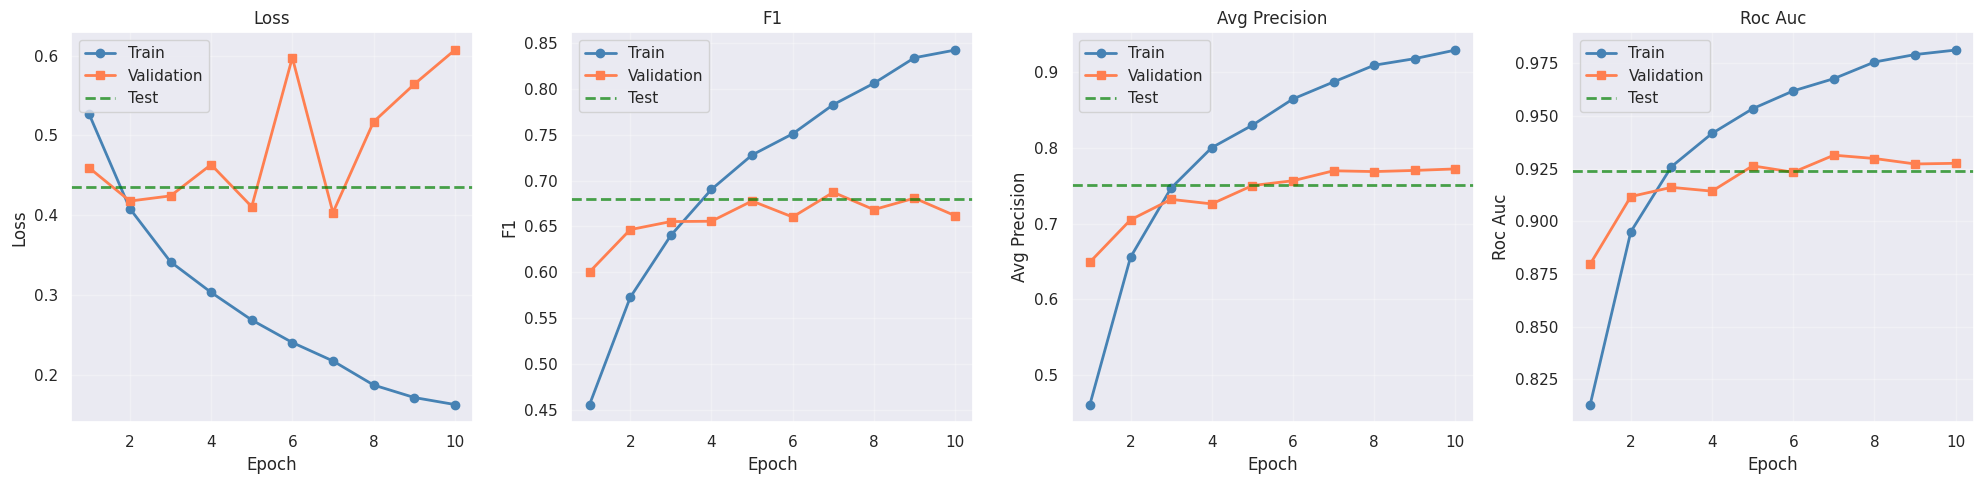

In [ ]:
# plot over epochs # choos metrics

# only f1 auc recall
# Plot F1 and Loss
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
sns.set_theme(style="darkgrid")

metrics = ['loss', 'f1', 'avg_precision', 'roc_auc']

for i, m in enumerate(metrics):

    # 1. F1 Score
    ax = axes[i]
    ax.plot(df_train['epoch'], df_train[m], marker='o', label='Train', linewidth=2, color='steelblue')
    ax.plot(df_val['epoch'], df_val[m], marker='s', label='Validation', linewidth=2, color='coral')
    ax.axhline(test_metrics[m], color='green', linestyle='--', linewidth=2, label='Test', alpha=0.7)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(m.replace('_', ' ').title())
    ax.set_title(m.replace('_', ' ').title())
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
# plt.savefig('plots/transformer_metrics_progression.pdf', dpi=300, bbox_inches='tight')
plt.show()

### Plotting simple models grid search

In [4]:
# for president the file was ran twice
dataset = "movies"

if dataset == "president":
    with open('rnn/res_json/model_test_results_20260324_004319.json', 'r') as f:
        ml_results_basic = json.load(f)

    # Load Linear SVM results
    with open('rnn/res_json/model_test_results_lin_scv_20260324_122136.json', 'r') as f:
        ml_results_linear_svm = json.load(f)

else:
    with open('results_json/movies_simple_model_20260326_124819.json', 'r') as f:
        ml_results_basic = json.load(f)

#    # Load Linear SVM results
#    with open('rnn/res_json/model_test_results_movies_lin_scv_20260324_122136.json', 'r') as f:
#        ml_results_linear_svm = json.load(f)

In [5]:
ml_basic_df = pd.DataFrame([
    {
        'prep': r['prep'],
        'vectorizer': r['vectorizer'],
        'model': r['model'],
        'status': r['status'],
        **{f'cv_{k}': v for k, v in r.get('cv_metrics', {}).items()},
        **{f'test_{k}': v for k, v in r.get('test_metrics', {}).items()}
    }
    for r in ml_results_basic
])

ml_combined = ml_basic_df.copy() 

if dataset == "president":
    ml_linear_svm_df = pd.DataFrame([
        {
            'prep': r['prep'],
            'vectorizer': r['vectorizer'],
            'model': 'linear_svm', 
            'status': r['status'],
            **{f'cv_{k}': v for k, v in r.get('cv_metrics', {}).items()},
            **{f'test_{k}': v for k, v in r.get('test_metrics', {}).items()}
        }
        for r in ml_results_linear_svm
    ])

    ml_basic_success = ml_basic_df[ml_basic_df['status'] == 'success'].copy() # svc failed heree
    ml_combined = pd.concat([ml_basic_success, ml_linear_svm_df], ignore_index=True)
print(ml_combined)

           prep     vectorizer                model   status     cv_f1  \
0   basic_lower  count_unigram          naive_bayes  success  0.799784   
1   basic_lower  count_unigram  logistic_regression  success  0.834327   
2   basic_lower  count_unigram           linear_svm  success  0.812703   
3   basic_lower  count_unigram              svm_rbf  success  0.780006   
4   basic_lower  count_unigram        random_forest  success  0.813471   
5   basic_lower   count_bigram          naive_bayes  success  0.812160   
6   basic_lower   count_bigram  logistic_regression  success  0.832937   
7   basic_lower   count_bigram           linear_svm  success  0.820762   
8   basic_lower   count_bigram              svm_rbf  success  0.795896   
9   basic_lower   count_bigram        random_forest  success  0.823005   
10  basic_lower  tfidf_unigram          naive_bayes  success  0.791337   
11  basic_lower  tfidf_unigram  logistic_regression  success  0.843128   
12  basic_lower  tfidf_unigram        

In [6]:
# plotting the top 10 models by f1
top_10 = ml_combined.nlargest(10, 'test_f1_macro')

# Select key metrics and normalize
metrics = ['test_f1_macro', 'test_roc_auc', 'test_avg_precision'] #  'test_recall_macro', 'test_precision_macro'
heatmap_data = top_10[['model', 'vectorizer', 'prep'] + metrics].copy()

# Create display labels
heatmap_data['config'] = (heatmap_data['model'].str[:10] + ' | ' + 
                          heatmap_data['vectorizer'].str[:7] + ' | ' + 
                          heatmap_data['prep'].str[:11])

# Normalize metrics to 0-1 range for better visualization
normalized_data = heatmap_data[metrics].copy()
for col in metrics:
    col_min = normalized_data[col].min()
    col_max = normalized_data[col].max()
    if col_max > col_min:
        normalized_data[col] = (normalized_data[col] - col_min) / (col_max - col_min)

# Plot heatmap
fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(normalized_data.set_index(heatmap_data['config']), 
            annot=heatmap_data[metrics].round(4).values, 
            fmt='g', cmap='YlGn', cbar_kws={'label': 'Relative score per metric'}, ax=ax, linewidths=0.5) #YlOrRd
ax.set_title('Top 10 models', fontsize=12, pad=20)
ax.set_xlabel('Metrics',  fontsize=11)
ax.set_ylabel('Model configuration', fontsize=11)
plt.xticks(rotation=0, ha='center')
plt.tight_layout()
# plt.savefig("images/top_10_models_heatmap.pdf", dpi=300)
plt.show()

KeyError: 'test_f1_macro'